In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv("../data/train.csv")

In [4]:
df.head(10)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
5,00025465d4725e87,"""\n\nCongratulations from me as well, use the ...",0,0,0,0,0,0
6,0002bcb3da6cb337,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,1,1,1,0,1,0
7,00031b1e95af7921,Your vandalism to the Matt Shirvington article...,0,0,0,0,0,0
8,00037261f536c51d,Sorry if the word 'nonsense' was offensive to ...,0,0,0,0,0,0
9,00040093b2687caa,alignment on this subject and which are contra...,0,0,0,0,0,0


In [5]:
df.shape

(159571, 8)

In [6]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='str')

In [7]:
df.drop(columns=["id"],inplace=True)

In [8]:
df.columns

Index(['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='str')

In [9]:
df.describe

<bound method NDFrame.describe of                                              comment_text  toxic  \
0       Explanation\nWhy the edits made under my usern...      0   
1       D'aww! He matches this background colour I'm s...      0   
2       Hey man, I'm really not trying to edit war. It...      0   
3       "\nMore\nI can't make any real suggestions on ...      0   
4       You, sir, are my hero. Any chance you remember...      0   
...                                                   ...    ...   
159566  ":::::And for the second time of asking, when ...      0   
159567  You should be ashamed of yourself \n\nThat is ...      0   
159568  Spitzer \n\nUmm, theres no actual article for ...      0   
159569  And it looks like it was actually you who put ...      0   
159570  "\nAnd ... I really don't think you understand...      0   

        severe_toxic  obscene  threat  insult  identity_hate  
0                  0        0       0       0              0  
1                  0   

In [10]:
df.info

<bound method DataFrame.info of                                              comment_text  toxic  \
0       Explanation\nWhy the edits made under my usern...      0   
1       D'aww! He matches this background colour I'm s...      0   
2       Hey man, I'm really not trying to edit war. It...      0   
3       "\nMore\nI can't make any real suggestions on ...      0   
4       You, sir, are my hero. Any chance you remember...      0   
...                                                   ...    ...   
159566  ":::::And for the second time of asking, when ...      0   
159567  You should be ashamed of yourself \n\nThat is ...      0   
159568  Spitzer \n\nUmm, theres no actual article for ...      0   
159569  And it looks like it was actually you who put ...      0   
159570  "\nAnd ... I really don't think you understand...      0   

        severe_toxic  obscene  threat  insult  identity_hate  
0                  0        0       0       0              0  
1                  0     

In [11]:
df.dtypes



comment_text       str
toxic            int64
severe_toxic     int64
obscene          int64
threat           int64
insult           int64
identity_hate    int64
dtype: object

In [12]:
non_str= df.drop(columns=['comment_text'])

In [13]:
non_str.isnull().sum()

toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [14]:
non_str.head()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0


In [15]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of                                              comment_text  toxic  \
0       Explanation\nWhy the edits made under my usern...      0   
1       D'aww! He matches this background colour I'm s...      0   
2       Hey man, I'm really not trying to edit war. It...      0   
3       "\nMore\nI can't make any real suggestions on ...      0   
4       You, sir, are my hero. Any chance you remember...      0   
...                                                   ...    ...   
159566  ":::::And for the second time of asking, when ...      0   
159567  You should be ashamed of yourself \n\nThat is ...      0   
159568  Spitzer \n\nUmm, theres no actual article for ...      0   
159569  And it looks like it was actually you who put ...      0   
159570  "\nAnd ... I really don't think you understand...      0   

        severe_toxic  obscene  threat  insult  identity_hate  
0                  0        0       0       0              0  
1             

In [16]:
df['comment_text'].isnull().sum()

np.int64(0)

In [17]:
import re
import html

def clean_comment(text):
    text = html.unescape(text)
    

    text = text.lower()

    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\b(?:\d{1,3}\.){3}\d{1,3}\b", " ", text)

    text = re.sub(r"=+\s*.*?\s*=+", " ", text)
    
    text = re.sub(r"[\r\n\t]+", " ", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df['cleaned_text'] = df['comment_text'].apply(clean_comment)


In [18]:
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,cleaned_text
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0,explanation why the edits made under my userna...
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0,d'aww! he matches this background colour i'm s...
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0,"hey man, i'm really not trying to edit war. it..."
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0,""" more i can't make any real suggestions on im..."
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0,"you, sir, are my hero. any chance you remember..."


In [19]:
df.drop(columns=['comment_text'], inplace=True)

In [20]:
df.head()

,toxic,severe_toxic,obscene,threat,insult,identity_hate,cleaned_text
0,0,0,0,0,0,0,explanation why the edits made under my userna...
1,0,0,0,0,0,0,d'aww! he matches this background colour i'm s...
2,0,0,0,0,0,0,"hey man, i'm really not trying to edit war. it..."
3,0,0,0,0,0,0,""" more i can't make any real suggestions on im..."
4,0,0,0,0,0,0,"you, sir, are my hero. any chance you remember..."


In [21]:
target_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

df[target_cols].sum()

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [22]:
df[target_cols].nunique()

toxic            2
severe_toxic     2
obscene          2
threat           2
insult           2
identity_hate    2
dtype: int64

=== Class Distribution ===
               Count  Percentage (%)
toxic          15294            9.58
severe_toxic    1595            1.00
obscene         8449            5.29
threat           478            0.30
insult          7877            4.94
identity_hate   1405            0.88


/tmp/ipykernel_8436/945520067.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


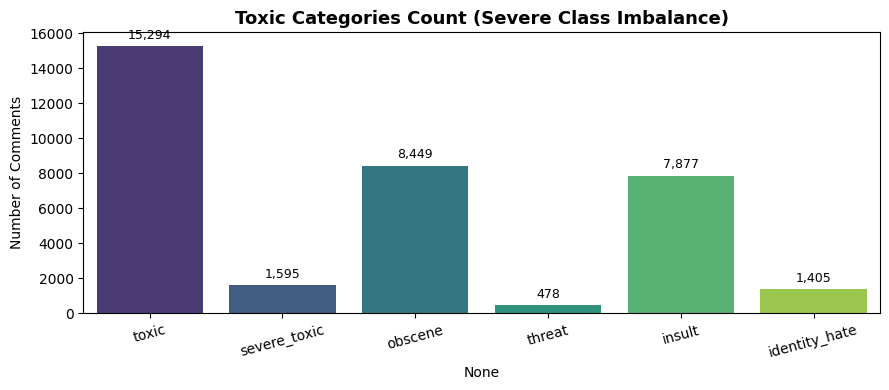

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

target_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# 1. Total counts and percentages
label_counts = df[target_cols].sum()
label_pcts = (label_counts / len(df)) * 100

eda_summary = pd.DataFrame({
    'Count': label_counts,
    'Percentage (%)': label_pcts.round(2)
})
print("=== Class Distribution ===")
print(eda_summary) 

# 2. Bar plot
plt.figure(figsize=(9, 4))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Toxic Categories Count (Severe Class Imbalance)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Comments')
plt.xticks(rotation=15)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()


Clean comments: 143,346 (89.83%)
Toxic comments: 16,225 (10.17%)


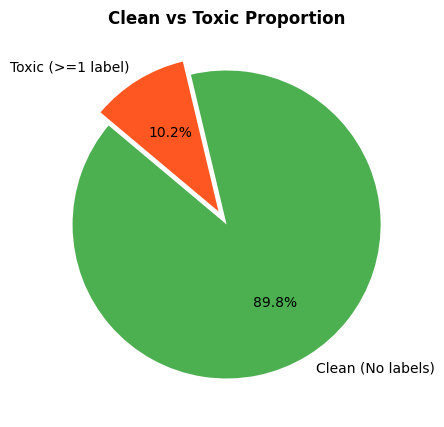

In [24]:
# Create a binary column: 0 = 100% clean, 1 = at least one toxic label
df['any_toxic'] = (df[target_cols].sum(axis=1) > 0).astype(int)

clean_count = (df['any_toxic'] == 0).sum()
toxic_count = (df['any_toxic'] == 1).sum()

print(f"Clean comments: {clean_count:,} ({clean_count/len(df)*100:.2f}%)")
print(f"Toxic comments: {toxic_count:,} ({toxic_count/len(df)*100:.2f}%)")

# Pie chart
plt.figure(figsize=(5, 5))
plt.pie([clean_count, toxic_count], labels=['Clean (No labels)', 'Toxic (>=1 label)'], 
        autopct='%1.1f%%', colors=['#4CAF50', '#FF5722'], explode=(0, 0.1), startangle=140)
plt.title('Clean vs Toxic Proportion', fontweight='bold')
plt.show()


In [25]:
from sklearn.model_selection import train_test_split

target_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

X = df['cleaned_text']
y = df[target_cols]

# 85% Train, 15% Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42
)


In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

vectorizer = FeatureUnion([
    ("word_tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=30000,
        sublinear_tf=True
    )),
    ("char_tfidf", TfidfVectorizer(
        ngram_range=(2, 6),
        analyzer="char",
        max_features=40000,
        sublinear_tf=True
    ))
])

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

print(f"Total features created: {X_train_vec.shape[1]:,}")


Total features created: 70,000


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

models = {}
val_probs = {}

print("Training 6 multi-label classifiers...")
for col in target_cols:
    print(f"--> Training classifier for: {col}")
    clf = LogisticRegression(
        C=2.5,
        max_iter=200,
        class_weight="balanced", 
        solver="saga",
        n_jobs=-1
    )
    clf.fit(X_train_vec, y_train[col])
    models[col] = clf
    val_probs[col] = clf.predict_proba(X_val_vec)[:, 1]

print("\nAll models trained successfully!")


Training 6 multi-label classifiers...
--> Training classifier for: toxic


/home/arav_exhausted/bsoc/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/arav_exhausted/bsoc/venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/arav_exhausted/bsoc/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--> Training classifier for: severe_toxic


/home/arav_exhausted/bsoc/venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/arav_exhausted/bsoc/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--> Training classifier for: obscene


...

/home/arav_exhausted/bsoc/venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/arav_exhausted/bsoc/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--> Training classifier for: insult


/home/arav_exhausted/bsoc/venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/arav_exhausted/bsoc/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


--> Training classifier for: identity_hate

All models trained successfully!


/home/arav_exhausted/bsoc/venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [28]:
import numpy as np

print("=== Validation ROC-AUC Scores ===")
auc_scores = []
for col in target_cols:
    auc = roc_auc_score(y_val[col], val_probs[col])
    auc_scores.append(auc)
    print(f"{col:15} | ROC-AUC: {auc:.4f}")

print(f"\nAverage ROC-AUC: {np.mean(auc_scores):.4f}")


=== Validation ROC-AUC Scores ===
toxic           | ROC-AUC: 0.9764
severe_toxic    | ROC-AUC: 0.9813
obscene         | ROC-AUC: 0.9869
threat          | ROC-AUC: 0.9898
insult          | ROC-AUC: 0.9772
identity_hate   | ROC-AUC: 0.9708

Average ROC-AUC: 0.9804
